In [61]:
# First, write a code where, by changing just the keyword, we can search for multiple things.
# Top 15 countries where the keywords are searched the most, and also create visual representation of it.
# A world map needs to be plotted showing the countries that search the keyword the most.
# We need to extract the time-wise interest of the keyword — how it trended in different years.

In [62]:
import pandas as pd
import numpy as nb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from pytrends.request import TrendReq # Needed in cases where we will send request to google for trend data

%matplotlib inline

##### Setup pytrend library and defind keyword

In [63]:
pytrends = TrendReq(hl = 'en-US', tz = 360)
                    # hl is language
                    # tz is time zone
keyword = "cloud computing"
                    # this keyword defined is subjective and can be changed later
                    # context : this for instance will be searched on google trends

##### Data request to google

##### First, write a code where, by changing just the keyword, we can search for multiple things.

In [64]:
# here we wish to know about keyword = "cloud computing" from google trends

pytrends.build_payload([keyword], cat = 0, timeframe = 'today 12-m', geo = '', gprop = '')
                                # cat = 0 states/ search result in all category
                                # timeframe = 'today 12-m'/ data required from today and past 12 m
                                # geo = ''/ data needed for entire globe
                                # gprop = ''/ need data of google search only not of youtube, google shopping etc


##### Top 15 countries where the keywords are searched the most, and also create visual representation of it.

In [65]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword, ascending = False).head(15)

TooManyRequestsError: The request failed: Google returned a response with code 429

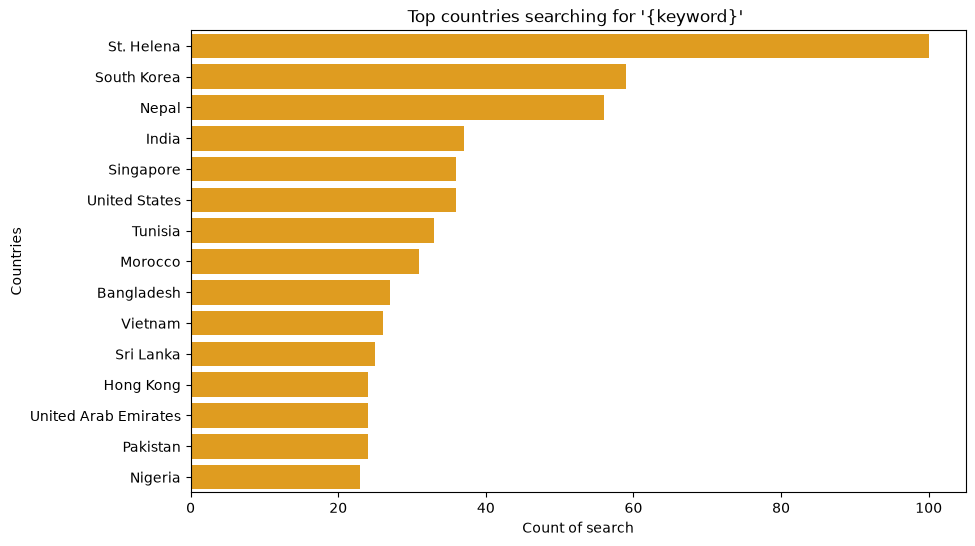

In [ ]:
plt.figure(figsize = (10,6))
sns.barplot(x = region_data[keyword], y = region_data.index, color = 'orange')

plt.title("Top countries searching for '{keyword}' ")
plt.xlabel('Count of search')
plt.ylabel('Countries')

plt.show()

##### A world map needs to be plotted showing the countries that search the keyword the most.

In [ ]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data,
                    locations = 'geoName',
                    locationmode = 'country names',
                    color = keyword,
                    title = f"Search Interest for '{keyword}' by country",
                    color_continuous_scale = 'oranges')

fig.show()

C:\Users\Shiva Thakur\AppData\Local\Temp\ipykernel_21112\3096159544.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(region_data,


##### We need to extract the time-wise interest of the keyword — how it trended in different years.

In [ ]:
time_df = pytrends.interest_over_time()

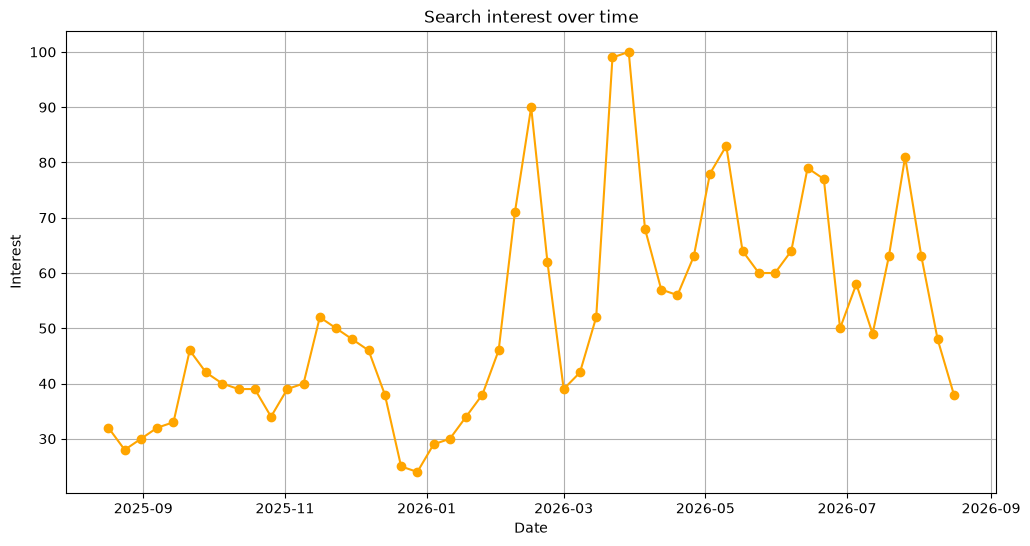

In [ ]:
plt.figure(figsize = (12,6))
plt.plot(time_df.index, time_df[keyword], marker = 'o', color = 'orange')

plt.title(f"Search interest over time")
plt.xlabel('Date')
plt.ylabel('Interest')
plt.grid(True)
plt.show()

##### Multiple keyword comparison

In [ ]:
kw_list = ['cloud computing', 'data science', 'Machine learning']
pytrends.build_payload(kw_list, cat = 0, timeframe = 'today 12-m', geo = '', gprop = '')

In [ ]:
## 45